# OSR-303 Side-Channel Acquisition Example

## Connection Diagram

We use a `PICO3206D` oscilloscope for signal acquisition, and place a 50-ohm impedance matcher at the acquisition interface to achieve impedance matching.

![image](images/sca-example.png)

The oscilloscope is controlled using the [pico3000 Python control package](https://gitee.com/osr-tech/pico3000).

## Download the Project

As shown in `https://gitee.com/osr-tech/osr-303/blob/master/project/STM32CubeIDE-303Guide.md`, we use STM32CubeIDE to download the AES project.

## Communication Test

In [1]:
import serial
import random
import numpy as np

In [2]:
toe = serial.Serial('com9', 115200, timeout=0)

In [3]:
p = random.randbytes(16)
toe.write(p) # send the plaintext
c = toe.read(16) # read the ciphertext
print(p.hex(), c.hex())

be5b3f425dfe67ec44fb64928978286a 


## Oscilloscope Configuration

In [4]:
import pico3000

In [5]:
import matplotlib.pyplot as plt

In [6]:
plt.rcParams['figure.figsize'] = 20, 3

In [7]:
pico = pico3000.Pico3000A()

2024-11-26 19:49:24,816 - pico3000 - INFO - device <JZ227/0166> opened


### Configure the Channel

In [8]:
pico.set_channel(
    channel=pico3000.CHANNEL.CHANNELA, 
    coupling=pico3000.COUPLING.DC,
    vrange=pico3000.VRANGE.PICO_5V,
    offset=0,
    enable=True,
    acquire=True
)

In [9]:
pico.set_channel(
    channel=pico3000.CHANNEL.CHANNELB, 
    coupling=pico3000.COUPLING.AC,
    vrange=pico3000.VRANGE.PICO_200MV,
    offset=0.0,
    enable=True,
    acquire=True
)

### Configure the Trigger

In [10]:
pico.set_trigger(
    source=pico3000.CHANNEL.CHANNELA,
    threshold=1000, # mv
    delay=0
)

### Configure the Horizontal Parameters

In [ ]:
pico3000.timebase_to_sample_rate(2) # use a 250MHz sample rate

250.0

In [12]:
pico.set_acquire(
    pre_trigger=0,
    post_trigger=1000000,
    timebase=2 # 250MHz
)

2024-11-26 19:49:24,896 - pico3000 - INFO - sample rate set to 250.000000 MHz


### Try Capturing a Signal

In [13]:
pico.arm()

In [14]:
p = random.randbytes(16)
toe.write(p) # send the plaintext
c = toe.read(16) # read the ciphertext
print(p.hex(), c.hex())

07753c9ebea0e701fc5e1d59d30b9920 cb6adaaf68ba9fce3bf8eeafb5755177


In [15]:
sa = pico.acquire(pico3000.CHANNEL.CHANNELA)
sb = pico.acquire(pico3000.CHANNEL.CHANNELB) 

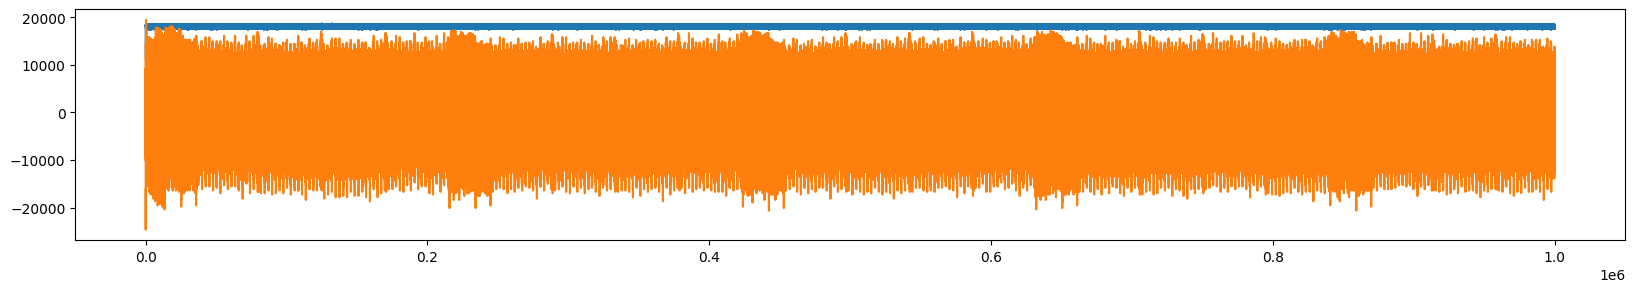

In [16]:
plt.plot(sa.T)
plt.plot(sb.T)
plt.show()

## Acquire ETS Traces

Using the [ets trace file](https://gitlab.com/eshard/estraces), you can store ets traces for compatibility with the OSR-ATLAS platform.

In [37]:
from estraces import ETSWriter

etsfile = ETSWriter("aes.ets", overwrite=True)
for i in tnrange(N):
    pico.arm() # oscilloscope waits for the trigger
    time.sleep(0.1)
    p = random.randbytes(16) # generate the plaintext
    toe.write(p) # send the plaintext
    c = toe.read(16) # read the ciphertext
    if c is None:
        print("failed to communicate")
        continue
    time.sleep(0.1) # wait for the oscilloscope data
    sb = pico.acquire(pico3000.CHANNEL.CHANNELB) 
    if sb is None:
        print("failed to acquire")
        continue
    etsfile.write_samples(sb[0], index=i)
    etsfile.write_metadata('plaintext', np.frombuffer(p, dtype=np.uint8), index=i)
    etsfile.write_metadata('ciphertext', np.frombuffer(c, dtype=np.uint8), index=i)

  0%|          | 0/400 [00:00<?, ?it/s]

In [38]:
import estraces

In [39]:
ths = estraces.read_ths_from_ets_file('aes.ets')

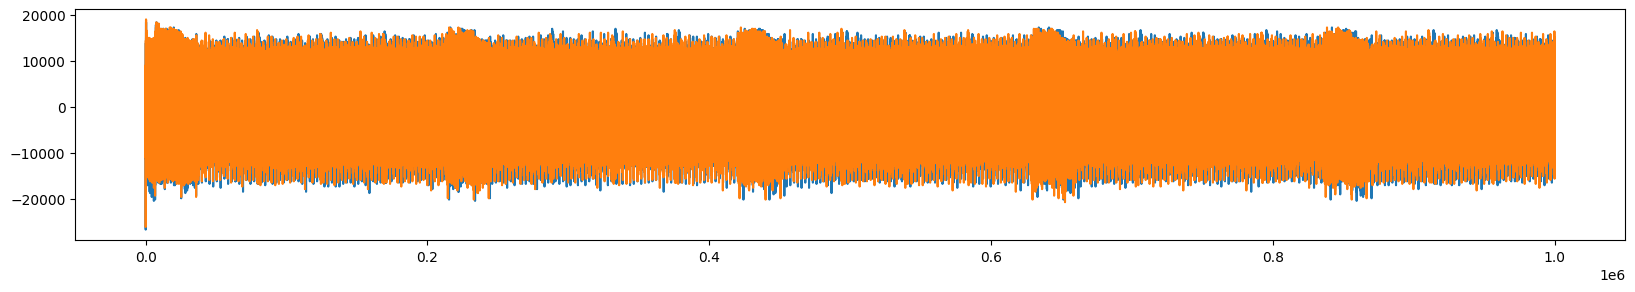

In [41]:
plt.plot(ths[0:2].samples.T)
plt.show()

In [42]:
ths[0:2].plaintext

array([[ 54,  17, 135, 216,  83,  17, 187, 191, 118, 172, 235,  69,  94,
         46,  60, 175],
       [ 82,  29, 154,  42, 134,  96, 134,  57, 167, 112,  50, 172,  64,
        161, 134, 103]], dtype=uint8)

## Acquire TRS Traces

Using the [trs trace file](https://github.com/Keysight/python-trsfile), you can store the trs format for compatibility with Inspector.

In [22]:
from trsfile import trs_open, Trace, SampleCoding, TracePadding, Header
from trsfile.parametermap import TraceParameterMap, TraceParameterDefinitionMap
from trsfile.traceparameter import ByteArrayParameter, ParameterType, TraceParameterDefinition
from tqdm.notebook import tnrange
import time


In [25]:
N = 400 # acquire 400 traces

In [ ]:
with trs_open(
		'aes.trs',                
		'w',                             
		engine = 'TrsEngine',            
		headers = {                      
			Header.TRS_VERSION: 2,
			Header.SCALE_X: 1.0/125e6, # 250MHz sample rate
			Header.SCALE_Y: 0.2, # 200mv
			Header.DESCRIPTION: 'AES Side Channel Trace',
			Header.TRACE_PARAMETER_DEFINITIONS: TraceParameterDefinitionMap({
                'plaintext': TraceParameterDefinition(ParameterType.BYTE, 16, 0), 
                'ciphertext': TraceParameterDefinition(ParameterType.BYTE, 16, 16), 
            })
		},
		padding_mode = TracePadding.AUTO,# Optional: padding mode (defaults to TracePadding.AUTO)
		live_update = False
	) as traces:

    for i in tnrange(N):
        pico.arm() # oscilloscope waits for the trigger
        time.sleep(0.1)
        p = random.randbytes(16) # generate the plaintext
        toe.write(p) # send the plaintext
        c = toe.read(16) # read the ciphertext
        if c is None:
            print("failed to communicate")
            continue
        time.sleep(0.1) # wait for the oscilloscope data
        sb = pico.acquire(pico3000.CHANNEL.CHANNELB) 
        if sb is None:
            print("failed to acquire")
            continue
        traces.append(
            Trace(
                SampleCoding.FLOAT,
                list(sb[0].astype(np.float32)), # sb is two-dimensional
                TraceParameterMap({'plaintext': ByteArrayParameter(p), 'ciphertext': ByteArrayParameter(c)})
        ))

  0%|          | 0/400 [00:00<?, ?it/s]

In [49]:
traces = trsfile.open('aes.trs', 'r')

Header.TRS_VERSION = 2
Header.SCALE_X = 7.999999773744548e-09
Header.SCALE_Y = 3.051757857974735e-06
Header.DESCRIPTION = AES Side Channel Trace
Header.TRACE_PARAMETER_DEFINITIONS = TraceParameterDefinitionMap([('plaintext', <TraceParameterDefinition: ByteArrayParameter of length 16 at offset 0>), ('ciphertext', <TraceParameterDefinition: ByteArrayParameter of length 16 at offset 16>)])
Header.SAMPLE_CODING = SampleCoding.FLOAT
Header.NUMBER_SAMPLES = 1000000
Header.NUMBER_TRACES = 400
Header.TITLE_SPACE = 255
Header.LENGTH_DATA = 32
Header.TRACE_SET_PARAMETERS = TraceSetParameterMap([('X_SCALE', <trsfile.traceparameter.FloatArrayParameter object at 0x00000239191755A0>), ('Y_SCALE', <trsfile.traceparameter.FloatArrayParameter object at 0x000002392859C040>), ('DISPLAY_HINT:X_LABEL', <trsfile.traceparameter.StringParameter object at 0x0000023919176EF0>), ('DISPLAY_HINT:Y_LABEL', <trsfile.traceparameter.StringParameter object at 0x000002392859C070>), ('DISPLAY_HINT:NUM_TRACES_SHOWN', <trs

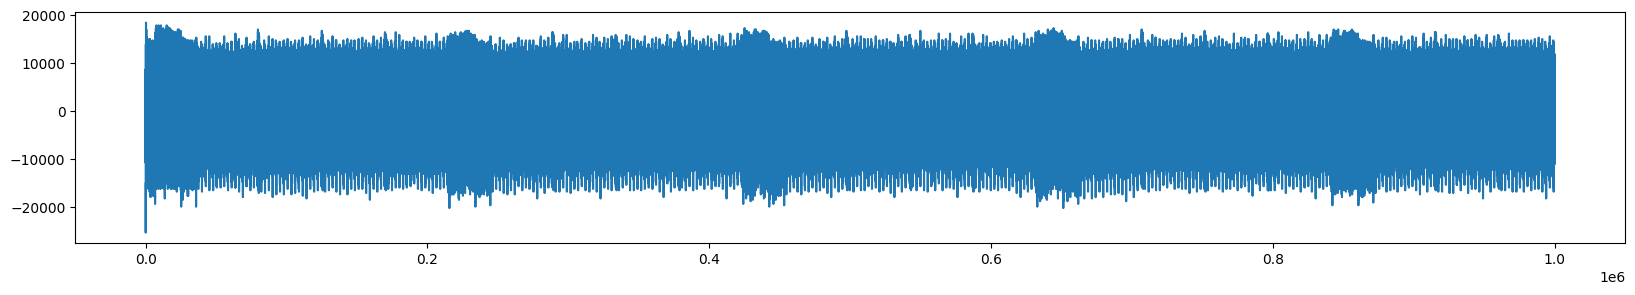

plaintext= [136, 103, 176, 19, 85, 80, 40, 143, 224, 106, 118, 135, 207, 213, 220, 140]


In [67]:
import trsfile

with trsfile.open('aes.trs', 'r') as traces:
	# Show all headers
    for header, value in traces.get_headers().items():
        print(header, '=', value)
    plt.plot(traces[0].samples)
    plt.show()
    print('plaintext=', traces[0].parameters['plaintext'].value)